In [135]:
import numpy as np
import pandas as pd
from copy import deepcopy

# don't forget to upload utils file to the colab session
import warnings, pylab

warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
pd.options.plotting.backend = "plotly"

df = pd.read_pickle('electronika_clean.pkl')
df

,Unnamed: 0,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
0,10,1303000511_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:46:45.000,201603,2016-03-05 09:16:49.000,2016-03-01 00:00:00.000,...,1,2970,0,2970,Ника,Товары для дома,Хозтовары,Техника для дома/Техника для ухода за одеждой/...,9,90364
1,12,1303000512_TT,556669108109_lm16@gmail.com,55574953-52525755535375,Онлайн-Резерв.,2016-03-01,10:47:19.000,201603,2016-03-01 10:59:43.000,2016-03-01 00:00:00.000,...,1,19490,0,19490,DeLonghi,Мелкая бытовая техника,Приготовление пищи,Техника для кухни/Приготовление пищи/Мультиварки/,9,45673
2,14,1303000513_TT,666668112117_pu19@ya.ru,55575655-50555350534877,Онлайн-Резерв.,2016-03-11,16:06:56.000,201603,2016-03-11 20:11:18.000,2016-03-12 00:00:00.000,...,1,19990,0,19990,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/LED телеви...",10,120757
3,16,1303000514_TT,666668112117_pu19@ya.ru,55575653-57485657505272,Онлайн-Резерв.,2016-03-15,18:13:33.000,201603,2016-03-15 18:17:35.000,2016-03-22 00:00:00.000,...,1,23680,0,23680,СМК,Мебель,Мягкая мебель,Мебель/Мягкая мебель/Диваны/Трехместные диваны/,11,264580
4,28,1303000520_TT,56666668112117_pu26@yanded.ru,55575449-54535553535073,Онлайн-Резерв.,2016-03-01,00:01:46.000,201603,2016-03-04 15:09:38.000,2016-03-02 00:00:00.000,...,1,2420,0,2420,HP,Аксессуары,Картриджи и бумага,"Компьютеры, ноутбуки, планшеты/Оргтехника/Расх...",9,76102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183067,357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,...,1,899,0,899,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17,38755
183068,357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,...,1,1090,0,1090,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17,31908
183069,357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,...,1,6859,0,6859,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17,140459
183070,357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,...,1,9120,0,9120,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17,295956


Text(0.5, 1.0, 'Goods total')

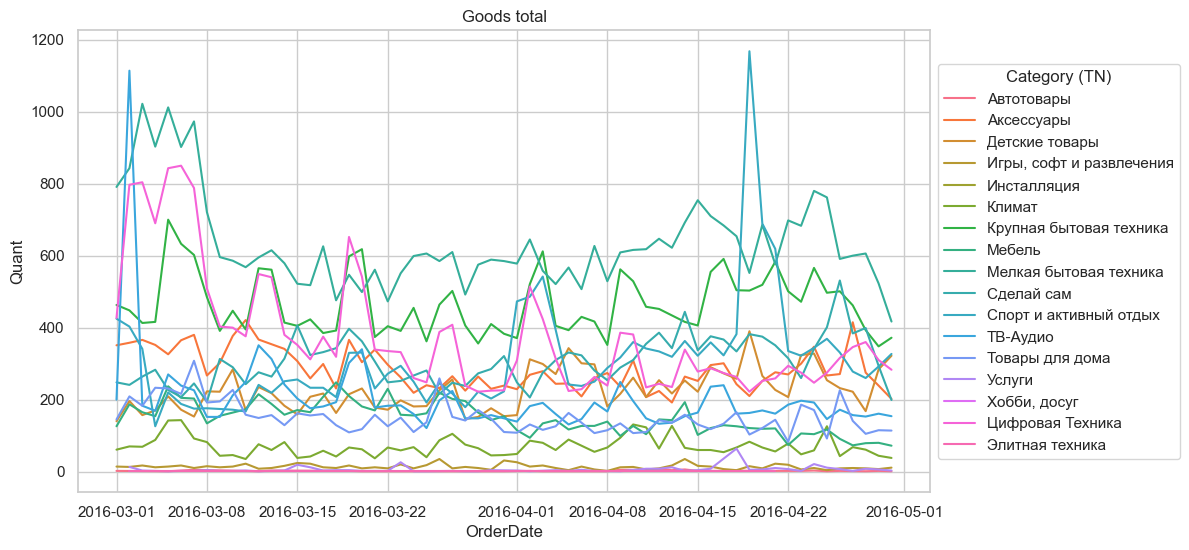

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

placed = df[['TN', 'OrderDate', 'Quant', 'RowSum']].groupby(['TN', 'OrderDate']).sum().reset_index()
placed['OrderDate'] = pd.to_datetime(placed['OrderDate'])

sns.set(style="whitegrid")
plt.figure(figsize=(11, 6))
sns.lineplot(data=placed, x='OrderDate', y='Quant', hue='TN')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Category (TN)")
plt.title('Goods total')


Text(0.5, 1.0, 'Goods sold')

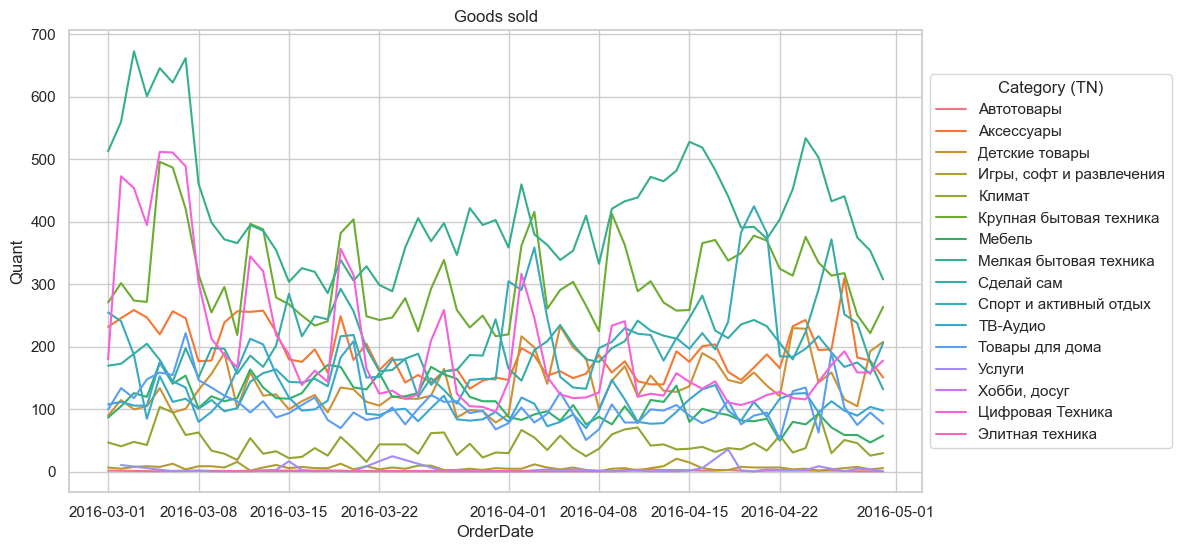

In [137]:
sold = df[df['Status_ID'] == 14][['TN', 'OrderDate', 'Quant']].groupby(['TN', 'OrderDate']).sum().reset_index()
sold['OrderDate'] = pd.to_datetime(sold['OrderDate'])

plt.figure(figsize=(11, 6))
sns.lineplot(data=sold, x='OrderDate', y='Quant', hue='TN')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Category (TN)")
plt.title('Goods sold')


## Крупная бытовая техника

In [138]:
category_name = 'Крупная бытовая техника'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend
OrderDate,,,,,
2016-03-01,463,20371.911447,1,1,0
2016-03-02,448,17828.104911,2,2,0
2016-03-03,413,18816.895884,3,3,0
2016-03-04,416,19055.516827,4,4,0
2016-03-05,700,18705.774286,5,5,1
2016-03-06,633,20151.616114,6,6,1
2016-03-07,602,18251.855482,0,7,0
2016-03-08,485,18521.775258,1,8,0
2016-03-09,391,18453.969309,2,9,0


In [139]:
from ipywidgets import IntProgress

from itertools import product
def percentile(n):
    '''Calculate n - percentile of data'''
    def percentile_(x):
        return np.percentile(x, n)
    percentile_.__name__ = 'pctl%s' % n
    return percentile_

# add missing dates to GroupBy.Core object
def fill_missing_dates(x, date_col, freq = None, default_value = np.nan):

    if freq is None:
        try:
           freq = pd.infer_freq(x.set_index(date_col).index[:min(100, x.shape[0])])
        except:
           freq = 'D'

        if freq is None:
          freq = 'D'
          Warning('TS freq is not defined! Daily granularity is provided!')
    # print(freq)
    # new indexes without time breaks
    idx = pd.date_range(x[date_col].min(), x[date_col].max(), freq=freq)
    # print(idx)
    results = x.set_index(date_col).reindex(idx,fill_value = default_value)
    results.index.rename(date_col, inplace = True)

    # groupby_day = x.groupby(pd.PeriodIndex(x[date_col], freq='D'))
    # results = groupby_day.sum(min_count=1)

    # idx = pd.period_range(min_date, max_date)
    # results = results.reindex(idx, fill_value=default_value)

    # results.index.rename(date_col, inplace=True)

    return results.reset_index()


def calc_preag_fill(data, group_col, date_col, target_cols, preagg_method):
    ## calc preaggregation
    data_preag = data.groupby(group_col).agg(
        preagg_method)[target_cols].reset_index()

    ## fill missing dates
    data_preag_filled = data_preag.groupby(group_col[:-1]).apply(
         fill_missing_dates, date_col=date_col).drop(group_col[:-1],
                                                     axis=1).reset_index()

    ## return DataFrame with calculated preaggregation and filled missing dates
    return data_preag # ,  data_preag_filled


def calc_rolling(data_preag_filled, group_col, date_col, method, w):

    ## calc rolling stats
    lf_df_filled = data_preag_filled.groupby(group_col[:-1]).\
        apply(lambda x: x.set_index(date_col).rolling(window=w, min_periods=1).agg(method)).drop(group_col[:-1], axis=1).reset_index(group_col)

    ## return DataFrame with rolled columns from target_vars
    return lf_df_filled

# ewma calculation method
def calc_ewm(data_preag_filled, group_col, date_col, span):
    ## calc ewm stats
    lf_df_filled = data_preag_filled.groupby(group_col[:-1]).\
        apply(lambda x: x.set_index(date_col).ewm(span=span).mean()).drop(group_col[:-1], axis=1).reset_index(group_col)

    ## return DataFrame with rolled columns from target_vars
    return lf_df_filled

# shift ts data
def shift(lf_df_filled, group_col, date_col, lag, kwargs = None):

    lf_df = (lf_df_filled.     # prepare calculations
        set_index(date_col).    # date column as time-index
        groupby(group_col[:-1]).       # ids_col to separate different time series
        apply(lambda x: x.shift(lag, kwargs)).    # aplly shift at lag steps
        drop(group_col[:-1], axis=1).                   # drop ids_col from time df to reset index
        reset_index()              # reset index to return df to no-index state
    )
    # lf_df[date_col] = pd.to_datetime(lf_df[date_col].astype(str))
    # print(lf_df.index)

    ## return DataFrame with following columns: filter_col, id_cols, date_col and shifted stats
    return lf_df


def generate_lagged_features(
        data: pd.DataFrame,
        target_cols: list = ['Demand'],
        id_cols: list = ['SKU_id', 'Store_id'],
        date_col: str = 'Date',
        lags: list = [7, 14, 21, 28],
        windows: list = ['7D', '14D', '28D', '56D'],
        preagg_methods: list = ['mean'],
        agg_methods: list = ['mean', 'median', percentile(10), pd.Series.skew],
        dynamic_filters: list = ['weekday', 'Promo'],
        ewm_params: dict = {'weekday': [14, 28], 'Promo': [14, 42]}) -> pd.DataFrame:

    '''
    data - dataframe with default index
    target_cols - column names for lags calculation
    id_cols - key columns to identify unique values
    date_col - column with datetime format values
    lags - lag values(days)
    windows - windows(days/weeks/months/etc.),
        calculation is performed within time range length of window
    preagg_methods - applied methods before rolling to make
        every value unique for given id_cols
    agg_methods - method of aggregation('mean', 'median', percentile, etc.)
    dynamic_filters - column names to use as filter
    ewm_params - span values(days) for each dynamic_filter
    '''

    data = data.sort_values(date_col)
    out_df = deepcopy(data)
    dates = [min(data[date_col]), max(data[date_col])]

    total = len(target_cols) * len(lags) * len(windows) * len(preagg_methods) * len(agg_methods) * len(dynamic_filters)
    progress = IntProgress(min=0, max=total)
    display(progress)

    for filter_col in dynamic_filters:
        group_col = [filter_col] + id_cols + [date_col]
        for preagg in preagg_methods:
          data_preag_filled = calc_preag_fill(data, group_col, date_col,
                                                  target_cols, preagg)

          ## add ewm features
          for alpha in ewm_params.get(filter_col, []):
              ewm_filled = calc_ewm(data_preag_filled, group_col,
                                    date_col, alpha)
              for lag in lags:
                ewm = shift(ewm_filled, group_col, date_col, lag)

                new_names = {x: "{0}_lag{1}d_alpha{2}_key{3}_preag{4}_{5}_dynamic_ewm".\
                    format(x, lag, alpha, '&'.join(id_cols), preagg, filter_col) for x in target_cols}

                out_df = pd.merge(out_df,
                                  ewm.rename(columns=new_names),
                                  how='left',
                                  on=group_col)

          ## add rolling features
          for w in windows:
              for method in agg_methods:
                  rolling_filled = calc_rolling(data_preag_filled,
                                                group_col, date_col,
                                                method, w)
                  for lag in lags:
                    ## lf_df - DataFrame with following columns: filter_col, id_cols, date_col, shifted rolling stats
                    rolling = shift(rolling_filled, group_col, date_col, lag)

                    method_name = method.__name__ if type(
                        method) != str else method

                    new_names = {x: "{0}_lag{1}d_w{2}_key{3}_preag{4}_ag{5}_{6}_dynamic_rolling".\
                                  format(x, lag, w, '&'.join(id_cols), preagg, method_name, filter_col) for x in target_cols}

                    out_df = pd.merge(out_df,
                                      rolling.rename(columns=new_names),
                                      how='left',
                                      on=group_col)
                    progress.value += 1

    return out_df

In [140]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,463,20371.911447,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,448,17828.104911,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,413,18816.895884,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,416,19055.516827,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,700,18705.774286,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,501,18830.427146,1,26,0,1,454.951991,439.660879,451.861188,...,374.6,364.7,552.1,515.3,442.00,442.35,361.4,370.1,532.3,599.4
57,2016-04-27,462,18735.835498,2,27,0,1,452.153234,436.626231,450.573897,...,374.6,364.7,552.1,515.3,440.95,443.60,361.4,370.1,532.3,599.4
58,2016-04-28,393,18964.488550,3,28,0,1,447.325092,425.300044,448.089806,...,377.6,360.5,552.1,515.3,443.65,431.30,369.5,361.4,532.3,530.1
59,2016-04-29,348,19003.589080,4,29,0,1,441.807442,443.586438,445.074401,...,396.6,360.5,552.1,549.7,440.75,428.50,369.5,361.4,532.3,525.1


In [141]:
for col in data_lagged_features.columns:
    print(data_lagged_features[col].isnull().value_counts())

OrderDate
False    61
Name: count, dtype: int64
Quant
False    61
Name: count, dtype: int64
RowSum
False    61
Name: count, dtype: int64
weekday
False    61
Name: count, dtype: int64
monthday
False    61
Name: count, dtype: int64
is_weekend
False    61
Name: count, dtype: int64
NoFilter
False    61
Name: count, dtype: int64
Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm
False    47
True     14
Name: count, dtype: int64
Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm
False    41
True     20
Name: count, dtype: int64
Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm
False    47
True     14
Name: count, dtype: int64
Quant_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm
False    41
True     20
Name: count, dtype: int64
Quant_lag14d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling
False    47
True     14
Name: count, dtype: int64
Quant_lag20d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling
False    41
True     20
Name: count, dtype: int64
Quant_lag14d_w14D_key_preags

In [142]:
data_lagged_features.iloc[:-14]

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,463,20371.911447,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,448,17828.104911,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,413,18816.895884,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,416,19055.516827,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,700,18705.774286,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2016-03-06,633,20151.616114,6,6,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2016-03-07,602,18251.855482,0,7,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2016-03-08,485,18521.775258,1,8,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2016-03-09,391,18453.969309,2,9,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2016-03-10,447,19709.512304,3,10,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

In [144]:
test_df

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
47,2016-04-17,591,19104.744501,6,17,1,1,455.376247,446.140663,453.904771,...,364.7,377.3,515.3,569.2,441.60,447.60,370.1,383.9,599.4,568.3
48,2016-04-18,504,18050.482143,0,18,0,1,448.614239,433.929390,450.230768,...,364.7,365.6,515.3,569.2,441.60,445.85,370.1,372.8,599.4,568.3
49,2016-04-19,503,17907.508946,1,19,0,1,441.155823,430.694606,445.957593,...,364.7,365.6,515.3,569.2,440.10,444.00,370.1,372.8,599.4,568.3
50,2016-04-20,519,16891.240848,2,20,0,1,439.660879,424.259118,444.772861,...,364.7,365.6,515.3,569.2,442.35,443.40,370.1,372.8,599.4,568.3
51,2016-04-21,583,16519.878216,3,21,0,1,436.626231,417.084268,442.721758,...,364.7,364.7,515.3,569.2,443.60,433.70,370.1,370.1,599.4,564.7
52,2016-04-22,501,18099.504990,4,22,0,1,425.300044,431.064041,436.054289,...,360.5,364.7,515.3,515.3,431.30,431.70,361.4,370.1,530.1,528.7
53,2016-04-23,472,18238.379237,5,23,1,1,443.586438,455.376247,445.268769,...,360.5,364.7,549.7,515.3,428.50,441.60,361.4,370.1,525.1,599.4
54,2016-04-24,566,19254.360424,6,24,1,1,455.007245,448.614239,451.369138,...,360.5,364.7,552.1,515.3,436.25,441.60,361.4,370.1,532.3,599.4
55,2016-04-25,497,18668.177062,0,25,0,1,455.407260,441.155823,451.850367,...,360.5,364.7,552.1,515.3,438.95,440.10,361.4,370.1,532.3,599.4
56,2016-04-26,501,18830.427146,1,26,0,1,454.951991,439.660879,451.861188,...,374.6,364.7,552.1,515.3,442.00,442.35,361.4,370.1,532.3,599.4


In [145]:
train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

In [146]:
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

In [147]:
print(X.dtypes)

categorical_features_indices = np.where(X.dtypes != float)[0]

RowSum                                                              float64
weekday                                                               int32
monthday                                                              int32
is_weekend                                                            int64
NoFilter                                                              int64
Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm              float64
Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
Quant_lag20d_alpha28_key_preagsum_NoFilter_dynamic_ewm              float64
Quant_lag14d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
Quant_lag20d_w14D_key_preagsum_agmean_NoFilter_dynamic_rolling      float64
Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling    float64
Quant_lag14d

In [148]:
from catboost import CatBoostRegressor, Pool, metrics, cv
from sklearn.metrics import mean_squared_error

In [149]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [150]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [151]:
train_pred

NameError: name 'train_pred' is not defined

In [152]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([574.95251455, 456.12999226, 426.18136198, 419.04764753,
       416.44181766, 418.8188804 , 562.54829071, 562.30206898,
       452.52875993, 417.86125579, 428.33799348, 431.45436828,
       409.80247605, 574.66400424])

In [153]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,,
2016-03-01,463,20371.911447,1,1,0,1,-1.000000
2016-03-02,448,17828.104911,2,2,0,1,-1.000000
2016-03-03,413,18816.895884,3,3,0,1,-1.000000
2016-03-04,416,19055.516827,4,4,0,1,-1.000000
2016-03-05,700,18705.774286,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,501,18830.427146,1,26,0,1,417.861256
2016-04-27,462,18735.835498,2,27,0,1,428.337993
2016-04-28,393,18964.488550,3,28,0,1,431.454368


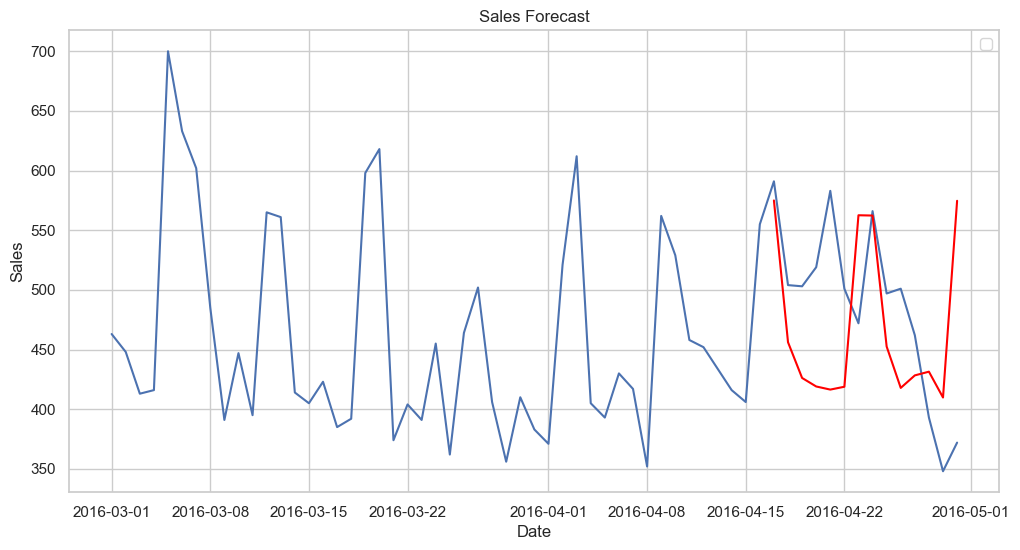

MAE: 74.84763190891441
MSE: 8395.894519587795
MAPE: 16.171879785196232


In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Мелкая бытовая техника

In [120]:
category_name = 'Мелкая бытовая техника'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend
OrderDate,,,,,
2016-03-01,791,4075.883692,1,1,0
2016-03-02,843,4347.794781,2,2,0
2016-03-03,1022,4155.894325,3,3,0
2016-03-04,903,4847.084164,4,4,0
2016-03-05,1012,4904.950593,5,5,1
2016-03-06,902,5066.451220,6,6,1
2016-03-07,973,4634.713258,0,7,0
2016-03-08,721,3944.643551,1,8,0
2016-03-09,596,4805.624161,2,9,0


In [121]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,791,4075.883692,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,843,4347.794781,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,1022,4155.894325,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,903,4847.084164,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,1012,4904.950593,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,591,4373.763113,1,26,0,1,591.759036,563.538699,591.912258,...,523.4,511.2,639.6,608.8,583.15,556.20,519.6,490.4,628.8,606.4
57,2016-04-27,600,4757.641667,2,27,0,1,595.798609,572.037164,594.080740,...,523.4,511.2,639.6,621.9,584.30,563.75,519.6,498.3,628.8,611.7
58,2016-04-28,606,5066.549505,3,28,0,1,608.645980,566.277166,601.116116,...,523.4,511.2,646.4,621.9,588.60,562.85,519.6,498.3,645.2,611.7
59,2016-04-29,523,5439.003824,4,29,0,1,628.053380,571.992212,612.069051,...,523.4,511.2,678.5,621.9,597.05,568.35,519.6,505.5,651.5,611.7


In [122]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

In [123]:
train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

In [124]:
model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [125]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [126]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([648.67680282, 684.75302577, 677.50348615, 738.76213925,
       666.81490879, 720.75329516, 654.85305714, 618.17646363,
       616.30860463, 669.42957301, 618.08320765, 652.45453382,
       624.85868016, 629.14528437])

In [127]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,,
2016-03-01,791,4075.883692,1,1,0,1,-1.000000
2016-03-02,843,4347.794781,2,2,0,1,-1.000000
2016-03-03,1022,4155.894325,3,3,0,1,-1.000000
2016-03-04,903,4847.084164,4,4,0,1,-1.000000
2016-03-05,1012,4904.950593,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,591,4373.763113,1,26,0,1,669.429573
2016-04-27,600,4757.641667,2,27,0,1,618.083208
2016-04-28,606,5066.549505,3,28,0,1,652.454534


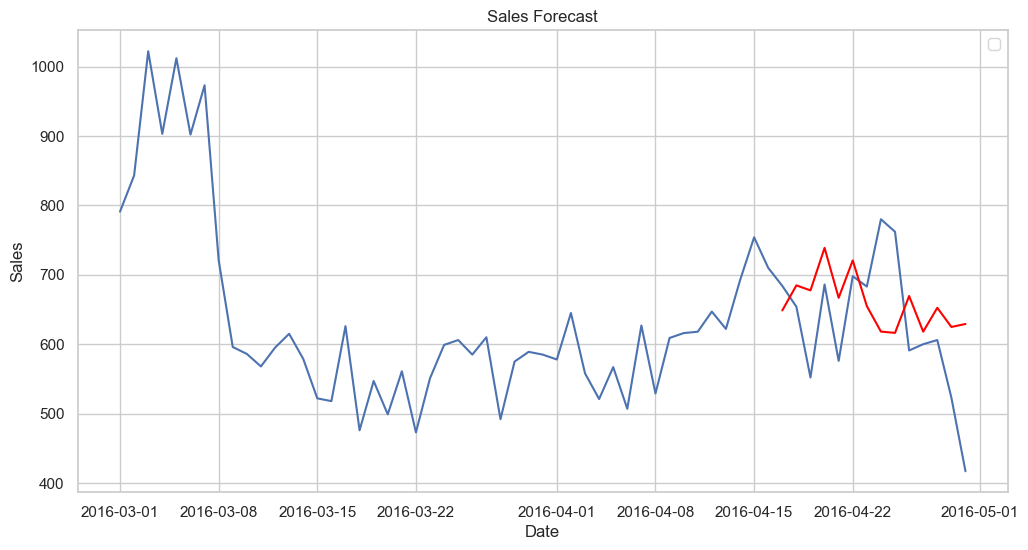

MAE: 82.18165756546334
MSE: 10122.545126208424
MAPE: 14.11484099413743


In [129]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Цифровая техника

In [55]:
category_name = 'Цифровая Техника'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend
OrderDate,,,,,
2016-03-01,427,14742.857143,1,1,0
2016-03-02,797,14608.587202,2,2,0
2016-03-03,804,16179.733831,3,3,0
2016-03-04,690,17465.007246,4,4,0
2016-03-05,843,12599.801898,5,5,1
2016-03-06,850,12129.991765,6,6,1
2016-03-07,788,11696.963198,0,7,0
2016-03-08,509,13541.442043,1,8,0
2016-03-09,403,17078.071960,2,9,0


In [56]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )
data_lagged_features

IntProgress(value=0, max=12)

,OrderDate,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Quant_lag14d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag20d_alpha14_key_preagsum_NoFilter_dynamic_ewm,Quant_lag14d_alpha28_key_preagsum_NoFilter_dynamic_ewm,...,Quant_lag14d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w14D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agmean_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl10_NoFilter_dynamic_rolling,Quant_lag14d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling,Quant_lag20d_w20D_key_preagsum_agpctl90_NoFilter_dynamic_rolling
0,2016-03-01,427,14742.857143,1,1,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-02,797,14608.587202,2,2,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-03,804,16179.733831,3,3,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-04,690,17465.007246,4,4,0,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-05,843,12599.801898,5,5,1,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2016-04-26,316,18647.648734,1,26,0,1,301.006732,317.841022,331.060649,...,225.3,224.3,412.6,419.2,298.85,337.45,224.9,224.9,409.6,516.8
57,2016-04-27,346,16295.572254,2,27,0,1,292.189585,310.496947,324.137372,...,226.9,224.3,412.6,419.2,297.60,334.65,224.9,224.9,409.6,516.8
58,2016-04-28,360,17960.772222,3,28,0,1,298.440958,300.927955,325.205234,...,230.5,224.3,412.6,419.2,302.15,314.00,224.9,224.9,409.6,433.0
59,2016-04-29,310,18235.893548,4,29,0,1,295.711720,312.308067,321.823348,...,230.5,224.3,412.6,419.2,296.65,306.20,224.9,224.9,409.6,409.6


In [57]:
train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

In [58]:
model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [59]:
X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

array([385.35897421, 352.93642528, 412.59887702, 405.67065662,
       360.48782931, 401.63642801, 318.4102658 , 321.97141231,
       337.77332458, 381.16990075, 432.37688717, 393.12804898,
       427.52882828, 356.38825769])

In [60]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,,
2016-03-01,427,14742.857143,1,1,0,1,-1.000000
2016-03-02,797,14608.587202,2,2,0,1,-1.000000
2016-03-03,804,16179.733831,3,3,0,1,-1.000000
2016-03-04,690,17465.007246,4,4,0,1,-1.000000
2016-03-05,843,12599.801898,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,316,18647.648734,1,26,0,1,381.169901
2016-04-27,346,16295.572254,2,27,0,1,432.376887
2016-04-28,360,17960.772222,3,28,0,1,393.128049


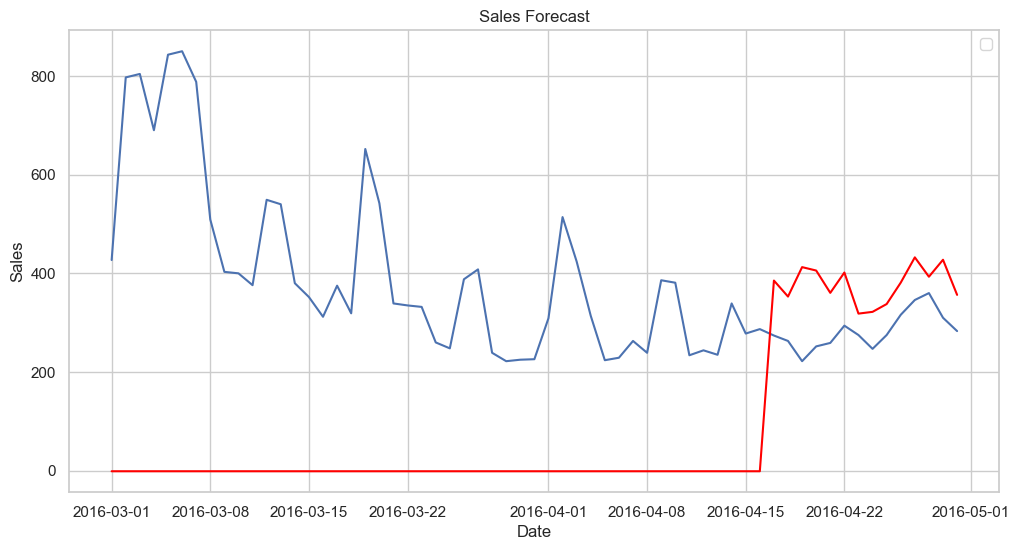

MAE: 93.67400828579291
MSE: 10411.95933431874
MAPE: 34.64781682146719


In [61]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index, daily_sales.Predictions, color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# Сделай Сам

In [130]:
category_name = 'Сделай сам'

placed1 = placed[placed['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']].set_index('OrderDate')
daily_sales = placed1.resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend
OrderDate,,,,,
2016-03-01,248,6594.322581,1,1,0
2016-03-02,241,5962.543568,2,2,0
2016-03-03,264,7091.981061,3,3,0
2016-03-04,283,5249.127208,4,4,0
2016-03-05,227,5338.158590,5,5,1
2016-03-06,207,5948.632850,6,6,1
2016-03-07,245,5423.787755,0,7,0
2016-03-08,194,5180.195876,1,8,0
2016-03-09,313,5096.872204,2,9,0


In [131]:
target_cols = ['Quant']
id_cols = []
date_col = 'OrderDate'
built_in_funcs = [pd.Series.kurtosis, pd.Series.skew]

# flts = {'Promo': {'oprm':'>0', 'npromo':'==0', 'aprm':'>-1'}, 'weekday' : {'md':'==0', 'tue':'==1', 'wd':'==2', 'th':'==3', 'fr':'==4', 'sa':'==5', 'su':'==6', 'anyday':'>-1'}}


daily_sales['NoFilter'] = 1
data_lagged_features = generate_lagged_features(daily_sales.reset_index()
                    , target_cols = target_cols
                    , id_cols = id_cols
                    , date_col = date_col
                    , lags = [14, 20] # min(lags)>= forecast horizon!
                    , windows = ['14D', '20D']
                    , preagg_methods = ['sum'] # ['mean', 'count']
                    , agg_methods = ['mean', percentile(10),  percentile(90)]
                    , dynamic_filters = ['NoFilter']
                    , ewm_params={'NoFilter': [14, 28]}
                    )

train_df, test_df = data_lagged_features.iloc[:-14], data_lagged_features.iloc[-14:]

train_df.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

model = CatBoostRegressor(
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    cat_features=categorical_features_indices,
    plot=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
predictions

IntProgress(value=0, max=12)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

array([321.65124812, 316.12705416, 324.1169434 , 311.38993908,
       320.38689432, 320.74292759, 300.04334444, 297.51779057,
       309.39018788, 307.48667698, 301.15726828, 298.06133391,
       315.82469112, 302.34696573])

In [132]:
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

,Quant,RowSum,weekday,monthday,is_weekend,NoFilter,Predictions
OrderDate,,,,,,,
2016-03-01,248,6594.322581,1,1,0,1,-1.000000
2016-03-02,241,5962.543568,2,2,0,1,-1.000000
2016-03-03,264,7091.981061,3,3,0,1,-1.000000
2016-03-04,283,5249.127208,4,4,0,1,-1.000000
2016-03-05,227,5338.158590,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,531,6355.617702,1,26,0,1,307.486677
2016-04-27,384,7455.968750,2,27,0,1,301.157268
2016-04-28,399,6992.403509,3,28,0,1,298.061334


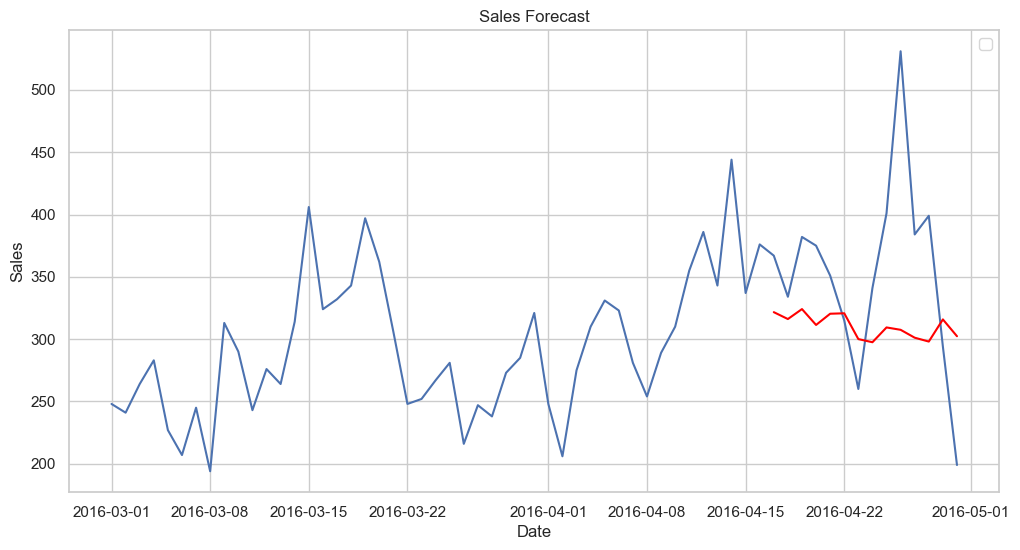

MAE: 66.33375658521825
MSE: 7199.711659591515
MAPE: 18.549064506413103


In [134]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')